Since our data is way unbalanced, use the following strategy to downsample our data:
crc03 and crc06 will be kept completely; crc09 and crc10 will be downsampled to the same amount of crc03 and crc06
inner stratification of those two: Glob_Patient * Tissue


HVG will be performed on dataset with reduced size

an scVI model will be trained on that data, and other non-selected cell will be projected via the model

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import scvi
import anndata as ad

In [ ]:
DATA_DIR = Path.home() / "project/crc-pm/result/label-transfer/qc_and_transferred.h5ad"
adata_full = sc.read_h5ad(DATA_DIR)
adata_full.obs["Study_Batch"] = adata_full.obs["Study"].astype(str) + "_" + adata_full.obs["Batch"].astype(str)

In [3]:
adata_large2 = adata_full[adata_full.obs['Study'].isin(['crc09', 'crc10-KUL3', 'crc10-SMC'])].copy()
adata_withpm = adata_full[adata_full.obs['Study'].isin(['crc03', 'crc06',])].copy()

In [4]:
# remove border line cell
border = (adata_large2.obs["Study"].astype(str).eq("crc10-KUL3")
    & adata_large2.obs["Sample"].astype(str).str.endswith("-B"))
adata_large2 = adata_large2[~border, :].copy()

In [5]:
# downsample
total_num_pm = adata_withpm.shape[0]
n_target = int(np.floor(total_num_pm / 2))

def sample_equal_by_patient(adata, n_target, seed=0):
    rng = np.random.default_rng(seed)
    groups = adata.obs.groupby("Glob_Patient", observed=True).groups
    # 每个 patient 先分到相同额度
    n_per_patient = int(np.floor(n_target / len(groups)))
    selected = []

    for cell_ids in groups.values():
        cell_ids = np.asarray(cell_ids)
        n = min(len(cell_ids), n_per_patient)
        selected.extend(rng.choice(cell_ids, size=n, replace=False))

    # 某些 patient 细胞不足时, 从剩余细胞中补齐
    n_missing = n_target - len(selected)

    if n_missing > 0:
        remaining = adata.obs_names.difference(selected)
        selected.extend(
            rng.choice(remaining, size=n_missing, replace=False)
        )
    return adata[selected].copy()

adata_large_crc = adata_large2[
    adata_large2.obs["Tissue"].astype(str) == "crc"
]

adata_large_normal = adata_large2[
    adata_large2.obs["Tissue"].astype(str) == "normal"
]

adata_large_crc = sample_equal_by_patient(
    adata_large_crc,
    n_target=n_target,
    seed=2026,
)

adata_large_normal = sample_equal_by_patient(
    adata_large_normal,
    n_target=n_target,
    seed=2025,
)
selected_cells = (
    adata_large_crc.obs_names.tolist()
    + adata_large_normal.obs_names.tolist()
    + adata_withpm.obs_names.tolist()
)

adata_train = adata_full[selected_cells].copy()
del adata_full


In [6]:
##### ===================
# HVG
##### ===================

# rule out non-protein coding genes, mitochondrial genes, ribosomal genes, and hemoglobin genes
candidate_gene = (
      adata_train.var["gene_biotype"].eq("protein_coding")
      & ~adata_train.var["mt"]
      & ~adata_train.var["ribo"]
      & ~adata_train.var["hb"]
  )

candidate_adata_train = adata_train[:, candidate_gene]
# per tissue HVG selection
for tissue in candidate_adata_train.obs["Tissue"].unique():
    tissue_adata = candidate_adata_train[candidate_adata_train.obs["Tissue"] == tissue].copy()
    match tissue:
        case 'crc':
            n_top_genes = 4000
        case 'normal':
            n_top_genes = 2000
        case 'pm':
            n_top_genes = 4000
    sc.pp.highly_variable_genes(
        tissue_adata,
        n_top_genes=n_top_genes,
        flavor="seurat_v3",
        layer="counts",
        batch_key="Study_Batch",
        subset=False,
        inplace=True,
    )
    adata_train.var[f"{tissue}_hvg"] = tissue_adata.var["highly_variable"]
adata_train.var["highly_variable"] = adata_train.var[["crc_hvg", "normal_hvg", "pm_hvg"]].any(axis=1)


In [7]:
for tissue in adata_train.obs["Tissue"].unique():
    print(f"{tissue} HVG count: {adata_train.var[f'{tissue}_hvg'].sum()}")

print(f"Total HVG count: {adata_train.var['highly_variable'].sum()}")
hvg_cols = ["crc_hvg", "pm_hvg", "normal_hvg"]
adata_train.var.loc[
    adata_train.var["highly_variable"],
    hvg_cols,
    ].value_counts()

crc HVG count: 4000
normal HVG count: 2000
pm HVG count: 4000
Total HVG count: 6024


crc_hvg  pm_hvg  normal_hvg
False    True    False         1507
True     False   False         1278
         True    False         1239
                 True          1072
         False   True           411
False    False   True           335
         True    True           182
Name: count, dtype: int64

In [24]:
HVG_gene = adata_train.var["highly_variable"]
HVG_gene.to_csv(
      str(Path.home() / "project/crc-pm/result/hvg" / "hvg_flags.tsv"),
      sep="\t",
      index=True,
      index_label="gene_id",
  )


### scVI training

In [8]:
##### ===================
# scVI
##### ===================

### prepare AnnData object and model
batch_key = "Study_Batch"
adata_scvi = adata_train[:, adata_train.var["highly_variable"]].copy()
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_key)
model_scvi = scvi.model.SCVI(
      adata_scvi,
      n_latent=20,
      n_layers=2,
      gene_likelihood="nb",
      dispersion="gene",
  )

In [9]:
model_scvi.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.1.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': 'Study_Batch',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   6   │
│         n_cells          │ 62229 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 6024  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                        batch State Registry                         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃    Categories    ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Study_Batch'] │   crc03_scRNA    │          0          │
│                          │   crc06_snRNA    │          1          │
│                          │   crc09_SC3Pv2   │          2          │
│                          │   crc09_SC3Pv3   │          3          │
│                          │ crc10-KUL3_scRNA │          4          │
│                          │ crc10-SMC_scRNA  │          5          │
└──────────────────────────┴──────────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [10]:
max_epochs_scvi = int(np.min([round((20000 / adata_scvi.n_obs) * 400), 400]))
print(max_epochs_scvi)

129


In [11]:
model_scvi.train(
    max_epochs = max_epochs_scvi,
    early_stopping = True,
    batch_size=512,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhekai/miniconda3/envs/scarches/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
/home/zhekai/miniconda3/envs/scarches/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` a

Training:   0%|          | 0/129 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=129` reached.


In [19]:
model_dir = Path.home() / "project/crc-pm/result/scvi/scvi_model"
model_scvi.save(model_dir, overwrite=True)

In [12]:
adata_train.obsm["X_scVI"] = model_scvi.get_latent_representation()

In [16]:
sc.pp.neighbors(
    adata_train,
    use_rep="X_scVI",
    n_neighbors=30,
    metric="euclidean",
    random_state=2026,
)

sc.tl.umap(
    adata_train,
    min_dist=0.3,
    random_state=2026,
)

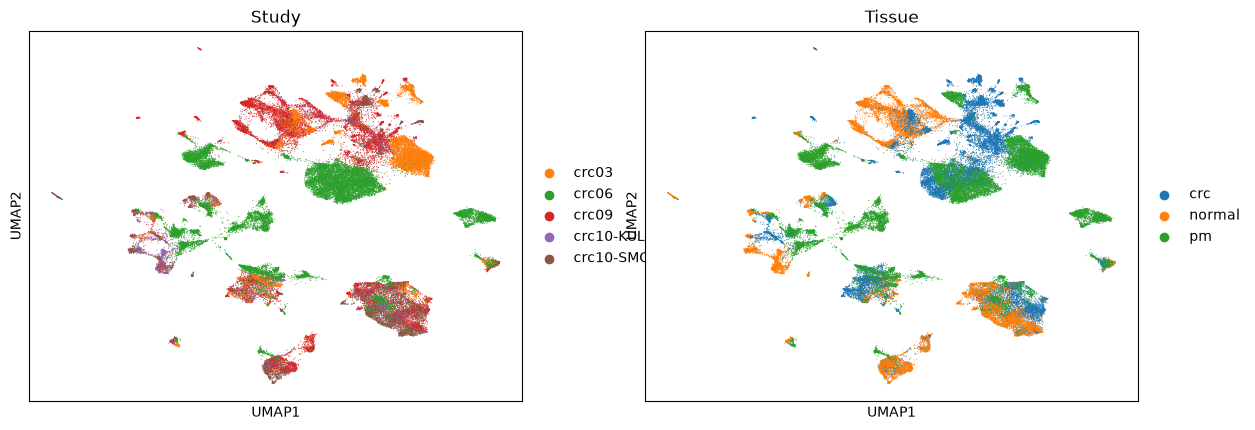

In [17]:
sc.pl.umap(
    adata_train,
    color=[
        "Study",
        "Tissue",
    ],)